In [ ]:
import importlib
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import yaml
from IPython.display import Audio, display
from tqdm import tqdm

import robustness.audio_functions.audio_transforms as at
import robustness.audio_models as architectures
from lightning_scripts.lightning_classifier_matched_speech_in_noise import (
    LitWordAudioSetModel,
)
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL

torch.set_float32_matmul_precision("medium")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


# Import tone perfect dataset metadata

In [ ]:
tone_perfect_dir = Path("~/ceph/datasets/tone_perfect").expanduser()
tp_metadata = pd.read_csv(tone_perfect_dir / "audio_metadata.csv")
tp_metadata.head()

tone_perfect_SR = 44100
model_sr = 20_000

In [3]:
tp_metadata.sort_values(by=['base_syllable', 'tone', 'speaker'])

,file_name,pinyin,syllable,base_syllable,tone,speaker
9696,downloaded_audio/ā_tone1_Female_Voice_1.mp3,ā,a1,a,1,female_voice_1
9697,downloaded_audio/ā_tone1_Female_Voice_2.mp3,ā,a1,a,1,female_voice_2
9698,downloaded_audio/ā_tone1_Female_Voice_3.mp3,ā,a1,a,1,female_voice_3
9699,downloaded_audio/ā_tone1_Male_Voice_1.mp3,ā,a1,a,1,male_voice_1
9700,downloaded_audio/ā_tone1_Male_Voice_2.mp3,ā,a1,a,1,male_voice_2
...,...,...,...,...,...,...
4957,downloaded_audio/nàn_tone4_Female_Voice_2.mp3,nàn,nan4,NaN,4,female_voice_2
4958,downloaded_audio/nàn_tone4_Female_Voice_3.mp3,nàn,nan4,NaN,4,female_voice_3
4959,downloaded_audio/nàn_tone4_Male_Voice_1.mp3,nàn,nan4,NaN,4,male_voice_1
4960,downloaded_audio/nàn_tone4_Male_Voice_2.mp3,nàn,nan4,NaN,4,male_voice_2


In [4]:
from torchaudio.transforms import Resample


def load_audio(rel_path, tone_perfect_dir=tone_perfect_dir):
    audio_path = tone_perfect_dir / rel_path
    audio, sr = torchaudio.load(str(audio_path))
    return audio, sr


class TonePerfectDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        tone_perfect_dir,
        resample_sr=20_000,
        pair_mode=False,
        include_negative=True,
        allow_tone1=False,
    ):
        tp_metadata = pd.read_csv(tone_perfect_dir / "audio_metadata.csv")
        if not allow_tone1:
            tp_metadata = tp_metadata[tp_metadata.tone != 1]
        self.metadata = tp_metadata
        self.talker_ids = tp_metadata.speaker.unique()
        self.base_syllables = tp_metadata.base_syllable.unique()
        self.tones = tp_metadata.tone.unique()
        self.pair_mode = pair_mode
        self.include_negative = include_negative
        if resample_sr is not None:
            self.resamp = Resample(tone_perfect_SR, resample_sr)
        else:
            self.resamp = None

        # cache speaker/tone combos that have at least two base syllables
        self.valid_pair_keys = [
            (spk, tone)
            for (spk, tone), df in self.metadata.groupby(["speaker", "tone"])
            if df.base_syllable.nunique() >= 2
        ]

    def __len__(self):
        return len(self.metadata)

    def _load_and_resample(self, file_name):
        audio, _ = load_audio(file_name)
        audio = audio[0]  # mono
        if self.resamp is not None:
            audio = self.resamp(audio)
        return audio

    def __getitem__(self, idx):
        rng = np.random.RandomState(idx)

        if self.pair_mode:
            if len(self.valid_pair_keys) == 0:
                raise RuntimeError(
                    "No speaker/tone combinations with >=2 base syllables available."
                )

            # pick a talker/tone with at least two base syllables
            talker_id, tone = self.valid_pair_keys[
                rng.randint(0, len(self.valid_pair_keys))
            ]
            examples = self.metadata[
                (self.metadata.speaker == talker_id) & (self.metadata.tone == tone)
            ]
            base_choices = examples.base_syllable.unique()
            if len(base_choices) < 2:
                raise RuntimeError(
                    f"Insufficient base syllable variety for speaker {talker_id}, tone {tone}."
                )

            # robustly sample two bases that actually have rows
            max_tries = 10
            for _ in range(max_tries):
                chosen_bases = rng.choice(base_choices, size=2, replace=False)
                pair_audio, pair_syllables = [], []
                ok = True
                for base in chosen_bases:
                    base_examples = examples[examples.base_syllable == base]
                    if len(base_examples) == 0:
                        ok = False
                        break
                    row = base_examples.sample(random_state=rng).iloc[0]
                    pair_audio.append(self._load_and_resample(row.file_name))
                    pair_syllables.append(row.syllable)
                if ok:
                    break
            else:
                raise RuntimeError("Failed to sample two valid base syllables for this speaker/tone")

            negative_audio = None
            negative_meta = None
            if self.include_negative:
                neg_candidates = self.metadata[
                    (self.metadata.speaker == talker_id) & (self.metadata.tone != tone)
                ]
                if len(neg_candidates) > 0:
                    neg_row = neg_candidates.sample(random_state=rng).iloc[0]
                    negative_audio = self._load_and_resample(neg_row.file_name)
                    negative_meta = neg_row

            return {
                "audio_pair": pair_audio,
                "pair_syllables": pair_syllables,
                "pair_tone": tone,
                "speaker": talker_id,
                "negative_audio": negative_audio,
                "negative_meta": negative_meta,
            }

        # Original triplet sampling for tones 2/3/4 from same base syllable
        talker_id = rng.choice(self.talker_ids)
        base_syllable = rng.choice(self.base_syllables)
        examples = self.metadata[
            (self.metadata.speaker == talker_id)
            & (self.metadata.base_syllable == base_syllable)
        ]
        examples = examples.sort_values(by="tone")
        tone_audio = []
        syllables = examples.syllable.values
        for ix in range(min(3, len(examples))):
            tone_audio.append(self._load_and_resample(examples.iloc[ix].file_name))

        return {"audio": tone_audio, "syllables": syllables}


In [5]:
tp_dataset = TonePerfectDataset(
    tone_perfect_dir,
    model_sr,
    pair_mode=True,
    include_negative=True,
)

pair_batch = tp_dataset[1]
pair_audio, pair_syllables = pair_batch["audio_pair"], pair_batch["pair_syllables"]

for tone_audio, syllable in zip(pair_audio, pair_syllables):
    display(Audio(tone_audio, rate=model_sr))
    print(
        f"Positive pair: {syllable} (tone {pair_batch['pair_tone']}, speaker {pair_batch['speaker']})"
    )

if pair_batch["negative_audio"] is not None:
    display(Audio(pair_batch["negative_audio"], rate=model_sr))
    neg_meta = pair_batch["negative_meta"]
    print(f"Negative: {neg_meta.syllable} (tone {neg_meta.tone}, speaker {neg_meta.speaker})")



Positive pair: ran4 (tone 4, speaker female_voice_2)


Positive pair: cheng4 (tone 4, speaker female_voice_2)


Negative: deng2 (tone 2, speaker female_voice_2)


## Load model

In [6]:
from lightning_scripts.utils import model_build_utils
importlib.reload(model_build_utils)
from lightning_scripts.utils.model_build_utils import get_model

ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_lambda_0_model = get_model(ssl_lambda_0_config, layer_out='relu4')

ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")
ssl_lambda_5_model = get_model(ssl_lambda_5_config, layer_out='relu4')

word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
word_model = get_model(word_config, supervised=True, layer_out='relu4')

audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
audioset_model = get_model(audioset_config, supervised=True, layer_out='relu4')

multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
multitask_model = get_model(multitask_config, supervised=True, layer_out='relu4')

unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")
unbal_audioset_model = get_model(unbal_audioset_config, supervised=True, layer_out='relu4')


In [7]:
importlib.reload(at)

<module 'robustness.audio_functions.audio_transforms' from '/mnt/ceph/users/igriffith/projects/cochdnn/robustness/audio_functions/audio_transforms.py'>

In [8]:

crop_or_pad = at.CenterCropOrPad(40000)
db_spl = 60
set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(db_spl)


def _prepare_audio_list(audio_list):
    tformed_audio = []
    for wav in audio_list:
        wav = crop_or_pad(wav.squeeze())
        wav, _ = set_dbSPL(wav, None)
        if wav is None:
            continue
        tformed_audio.append(wav.unsqueeze(0))
    return tformed_audio


def process_batch(batch):
    audio = _prepare_audio_list(batch["audio"])
    audio = torch.stack(audio).cuda()
    return audio, batch["syllables"]


def process_pair_batch(batch):
    pair_audio = torch.stack(_prepare_audio_list(batch["audio_pair"])).cuda()
    negative_audio = None
    if batch.get("negative_audio") is not None:
        neg_list = _prepare_audio_list([batch["negative_audio"]])
        if len(neg_list):
            negative_audio = torch.stack(neg_list).cuda()
    return pair_audio, negative_audio, batch

pair_audio, negative_audio, pair_meta = process_pair_batch(tp_dataset[0])

In [9]:

def compute_contrastive_loss(z_anchor, z_pos, z_neg=None, temperature=0.1):
    z_anchor = F.normalize(z_anchor, dim=1)
    z_pos = F.normalize(z_pos, dim=1)

    pos_sim = torch.exp(torch.sum(z_anchor * z_pos, dim=1) / temperature)

    if z_neg is not None:
        z_neg = F.normalize(z_neg, dim=1)
        neg_sim = torch.exp(torch.sum(z_anchor * z_neg, dim=1) / temperature)
        loss = -torch.log(pos_sim / (pos_sim + neg_sim))
    else:
        loss = 1 - torch.sum(z_anchor * z_pos, dim=1)

    return loss


def encode_audio(model, audio_batch):
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
        return z


def process_pair(model, pair_audio, negative_audio=None, temperature=0.1):
    z_pair = encode_audio(model, pair_audio)
    z_anchor, z_pos = z_pair[0].unsqueeze(0), z_pair[1].unsqueeze(0)
    z_neg = encode_audio(model, negative_audio) if negative_audio is not None else None
    # flatten if z is more than 2D
    loss = compute_contrastive_loss(z_anchor, z_pos, z_neg, temperature)
    sims = {"pos_cos_sim": F.cosine_similarity(z_anchor, z_pos).item()}
    if z_neg is not None:
        sims["neg_cos_sim"] = F.cosine_similarity(z_anchor, z_neg).item()

    return loss, sims


def print_pair_results(loss, sims):
    print(f"Contrastive loss: {loss.mean().item():.4f}")
    print(f"Positive cosine similarity: {sims.get('pos_cos_sim', float('nan')):.4f}")
    if "neg_cos_sim" in sims:
        print(f"Negative cosine similarity: {sims['neg_cos_sim']:.4f}")


margin = 1

## process example

In [57]:
# contrastive evaluation of same-tone pair
loss, sims = process_pair(ssl_lambda_0_model, pair_audio, negative_audio)
print("ssl_lambda_0_model")
print_pair_results(loss, sims)


# contrastive evaluation of same-tone pair
loss, sims = process_pair(ssl_lambda_5_model, pair_audio, negative_audio)
print("ssl_lambda_5_model")
print_pair_results(loss, sims)

# contrastive evaluation of same-tone pair
loss, sims = process_pair(word_model, pair_audio, negative_audio)
print("word_model")
print_pair_results(loss, sims)

# contrastive evaluation of same-tone pair
loss, sims = process_pair(audioset_model, pair_audio, negative_audio)
print("audioset_model")
print_pair_results(loss, sims)


ssl_lambda_0_model
Contrastive loss: 0.6163
Positive cosine similarity: 0.5289
Negative cosine similarity: 0.5129
ssl_lambda_5_model
Contrastive loss: 0.6146
Positive cosine similarity: 0.5707
Negative cosine similarity: 0.5543
word_model
Contrastive loss: 0.5366
Positive cosine similarity: 0.2816
Negative cosine similarity: 0.2474
audioset_model
Contrastive loss: 0.1470
Positive cosine similarity: 0.7202
Negative cosine similarity: 0.5360


In [14]:
import matplotlib.pyplot as plt


,example_idx,model,speaker,tone,syllable_a,syllable_b,loss,pos_cos_sim,neg_cos_sim
0,0,audioset_model,male_voice_2,2,se2,fang2,0.147023,0.720238,0.535963
1,0,word_model,male_voice_2,2,se2,fang2,0.536600,0.281597,0.247373
2,0,ssl_lambda_0_model,male_voice_2,2,se2,fang2,0.616307,0.528876,0.512868
3,0,ssl_lambda_5_model,male_voice_2,2,se2,fang2,0.614594,0.570728,0.554347
4,1,audioset_model,female_voice_2,4,ran4,cheng4,1.319045,0.733983,0.834773


/tmp/ipykernel_301169/3982067633.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_301169/3982067633.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


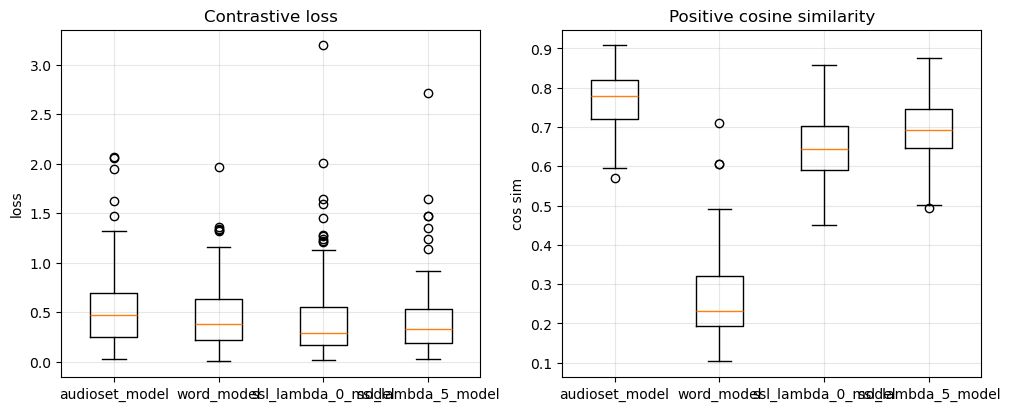

/tmp/ipykernel_301169/3982067633.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


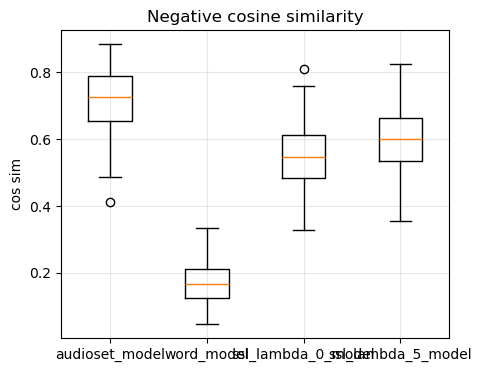

In [58]:
import matplotlib.pyplot as plt

num_examples = 100
contrastive_temperature = 0.1

records = []
for idx in range(num_examples):
    batch = tp_dataset[idx]
    pair_audio, negative_audio, meta = process_pair_batch(batch)

    for model_name, model in [
        ("audioset_model", audioset_model),
        ("word_model", word_model),
        ("ssl_lambda_0_model", ssl_lambda_0_model),
        ("ssl_lambda_5_model", ssl_lambda_5_model),
    ]:
        loss, sims = process_pair(
            model, pair_audio, negative_audio, temperature=contrastive_temperature
        )
        records.append(
            {
                "example_idx": idx,
                "model": model_name,
                "speaker": meta["speaker"],
                "tone": meta["pair_tone"],
                "syllable_a": meta["pair_syllables"][0],
                "syllable_b": meta["pair_syllables"][1],
                "loss": float(loss.mean().item()),
                "pos_cos_sim": sims.get("pos_cos_sim"),
                "neg_cos_sim": sims.get("neg_cos_sim"),
            }
        )

results_df = pd.DataFrame(records)
display(results_df.head())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
models_order = results_df.model.unique()

axes[0].boxplot(
    [results_df[results_df.model == m].loss.dropna() for m in models_order],
    labels=models_order,
)
axes[0].set_title("Contrastive loss")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(
    [results_df[results_df.model == m].pos_cos_sim.dropna() for m in models_order],
    labels=models_order,
)
axes[1].set_title("Positive cosine similarity")
axes[1].set_ylabel("cos sim")
axes[1].grid(True, alpha=0.3)

plt.show()

if results_df.neg_cos_sim.notna().any():
    plt.figure(figsize=(5, 4))
    plt.boxplot(
        [results_df[results_df.model == m].neg_cos_sim.dropna() for m in models_order],
        labels=models_order,
    )
    plt.title("Negative cosine similarity")
    plt.ylabel("cos sim")
    plt.grid(True, alpha=0.3)
    plt.show()



,example_idx,model,speaker,tone,syllable_a,syllable_b,neg_tone,loss,pos_l2_sq,neg_l2_sq
0,0,audioset_model,male_voice_2,2,se2,fang2,4,0.301466,41624.882812,6.389611e+04
1,0,word_model,male_voice_2,2,se2,fang2,4,2.114984,889095.437500,2.136950e+06
2,0,ssl_lambda_0_model,male_voice_2,2,se2,fang2,4,0.510493,40605.199219,3.985937e+04
3,0,ssl_lambda_5_model,male_voice_2,2,se2,fang2,4,0.464174,27078.134766,2.752259e+04
4,1,audioset_model,female_voice_2,4,ran4,cheng4,2,0.650355,26093.929688,1.296317e+04


/tmp/ipykernel_301169/672559640.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_301169/672559640.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/tmp/ipykernel_301169/672559640.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


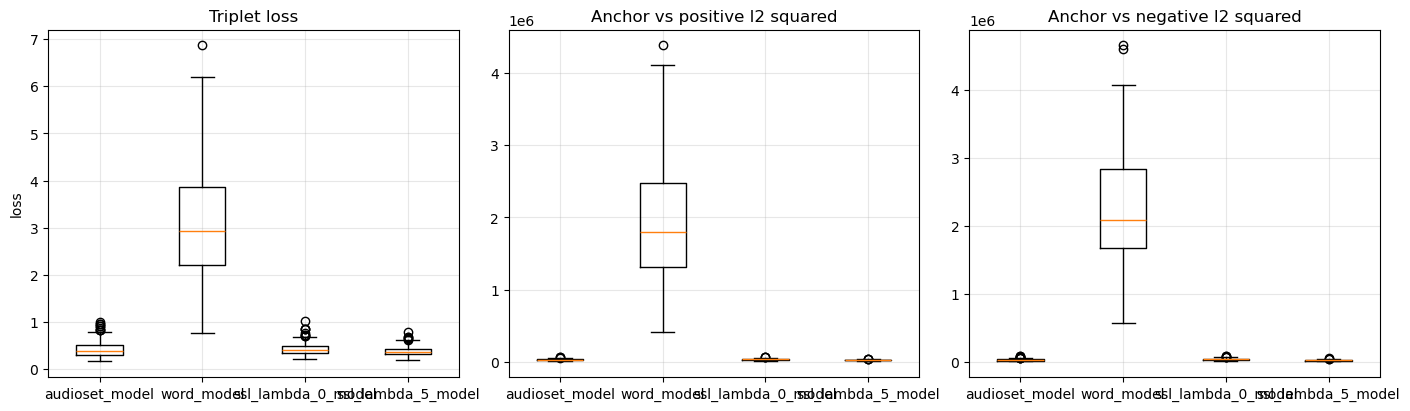

In [ ]:
# Triplet-loss sweep (same-tone positive pair, different-tone negative)
num_triplet_examples = 200
triplet_margin = 0.2

triplet_ds = TonePerfectDataset(
    tone_perfect_dir,
    model_sr,
    pair_mode=True,  # two positives: same speaker/tone, different base syllables
    include_negative=True,  # negative: same speaker, different tone
    allow_tone1=False,
)

triplet_records = []
example_idx = 0
idx = 0
while example_idx < num_triplet_examples and idx < num_triplet_examples * 5:
    batch = triplet_ds[idx]
    idx += 1
    pair_audio, negative_audio, meta = process_pair_batch(batch)
    if negative_audio is None:
        continue

    for model_name, model in [
        ("multitask_model", multitask_model),
        ("audioset_model", audioset_model), 
        ("word_model", word_model),
        ("ssl_lambda_0_model", ssl_lambda_0_model),
        ("ssl_lambda_5_model", ssl_lambda_5_model),
    ]:
        with torch.no_grad():
            z_pair = model(pair_audio)
            z_neg = model(negative_audio)
        if z_pair.shape[0] < 2 or z_neg.shape[0] < 1:
            continue
        z_anchor, z_pos = z_pair[0].unsqueeze(0), z_pair[1].unsqueeze(0)
        z_neg_ex = z_neg[0].unsqueeze(0)

        loss = F.triplet_margin_loss(
            z_anchor, z_pos, z_neg_ex, margin=triplet_margin, reduction="none"
        )
        pos_l2_sq = float(torch.sum((z_anchor - z_pos) ** 2).item())
        neg_l2_sq = float(torch.sum((z_anchor - z_neg_ex) ** 2).item())

        triplet_records.append(
            {
                "example_idx": example_idx,
                "model": model_name,
                "speaker": meta.get("speaker", None),
                "tone": meta.get("pair_tone", None),
                "syllable_a": meta.get("pair_syllables", [None, None])[0],
                "syllable_b": meta.get("pair_syllables", [None, None])[1],
                "neg_tone": meta.get("negative_meta", {}).tone if meta.get("negative_meta") is not None else None,
                "loss": float(loss.mean().item()),
                "pos_l2_sq": pos_l2_sq,
                "neg_l2_sq": neg_l2_sq,
            }
        )
    example_idx += 1

triplet_df = pd.DataFrame(triplet_records)
display(triplet_df.head())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
models_order = triplet_df.model.unique()

axes[0].boxplot(
    [triplet_df[triplet_df.model == m].loss.dropna() for m in models_order],
    labels=models_order,
)
axes[0].set_title("Triplet loss")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(
    [triplet_df[triplet_df.model == m].pos_l2_sq.dropna() for m in models_order],
    labels=models_order,
)
axes[1].set_title("Anchor vs positive l2 squared")
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(
    [triplet_df[triplet_df.model == m].neg_l2_sq.dropna() for m in models_order],
    labels=models_order,
)
axes[2].set_title("Anchor vs negative l2 squared")
axes[2].grid(True, alpha=0.3)

plt.show()



In [10]:
# Triplet-loss sweep (same-tone positive pair, different-tone negative)
num_triplet_examples = 200

tp_dataset = TonePerfectDataset(
    tone_perfect_dir,
    model_sr,
    pair_mode=True,  # two positives: same speaker/tone, different base syllables
    include_negative=True,  # negative: same speaker, different tone
    allow_tone1=False,
)

records = []
example_idx = 0
idx = 0
while example_idx < num_triplet_examples and idx < num_triplet_examples * 5:
    batch = tp_dataset[idx]
    idx += 1
    pair_audio, negative_audio, meta = process_pair_batch(batch)
    if negative_audio is None:
        continue

    for model_name, model in [
        ("multitask_model", multitask_model),
        ("unbal_audioset_model", unbal_audioset_model),
        ("audioset_model", audioset_model), 
        ("word_model", word_model),
        ("ssl_lambda_0_model", ssl_lambda_0_model),
        ("ssl_lambda_5_model", ssl_lambda_5_model),
    ]:

        z_pair = encode_audio(model, pair_audio)
        z_neg = encode_audio(model, negative_audio)
        if z_pair.shape[0] < 2 or z_neg.shape[0] < 1:
            continue
        z_anchor, z_pos = z_pair[0].unsqueeze(0), z_pair[1].unsqueeze(0)
        z_neg_ex = z_neg[0].unsqueeze(0)

        
        # use 2 nomrm 
        pos_l2_norm = float(torch.norm(z_anchor - z_pos, p=2).item())
        neg_l2_norm = float(torch.norm(z_anchor - z_neg_ex, p=2).item())

        l2_judgement = int((pos_l2_norm < neg_l2_norm)) 

        # use squared l2 norm 
        pos_l2_sq = pos_l2_norm ** 2 
        neg_l2_sq = neg_l2_norm ** 2 
        sqr_l2_judgement = int((pos_l2_sq < neg_l2_sq))

        # use cosine similarity 
        pos_cos_sim = float(F.cosine_similarity(z_anchor, z_pos).item())
        neg_cos_sim = float(F.cosine_similarity(z_anchor, z_neg_ex).item())

        cos_judgement = int((pos_cos_sim > neg_cos_sim))

        # ust

        records.append(
            {
                "example_idx": example_idx,
                "model": model_name,
                "speaker": meta.get("speaker", None),
                "tone": meta.get("pair_tone", None),
                "syllable_a": meta.get("pair_syllables", [None, None])[0],
                "syllable_b": meta.get("pair_syllables", [None, None])[1],
                "neg_tone": meta.get("negative_meta", {}).tone if meta.get("negative_meta") is not None else None,
                "l2_judgement": l2_judgement,
                "sqr_l2_judgement": sqr_l2_judgement,
                "cos_judgement": cos_judgement,
            }
        )
    example_idx += 1

triplet_df = pd.DataFrame(records)
display(triplet_df.head())





,example_idx,model,speaker,tone,syllable_a,syllable_b,neg_tone,l2_judgement,sqr_l2_judgement,cos_judgement
0,0,multitask_model,male_voice_2,2,se2,fang2,4,1,1,1
1,0,unbal_audioset_model,male_voice_2,2,se2,fang2,4,1,1,1
2,0,audioset_model,male_voice_2,2,se2,fang2,4,1,1,1
3,0,word_model,male_voice_2,2,se2,fang2,4,1,1,1
4,0,ssl_lambda_0_model,male_voice_2,2,se2,fang2,4,0,0,1


/tmp/ipykernel_313142/526218526.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ix].set_xticklabels(model_labels, rotation=90, ha='center')
/tmp/ipykernel_313142/526218526.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ix].set_xticklabels(model_labels, rotation=90, ha='center')
/tmp/ipykernel_313142/526218526.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[ix].set_xticklabels(model_labels, rotation=90, ha='center')


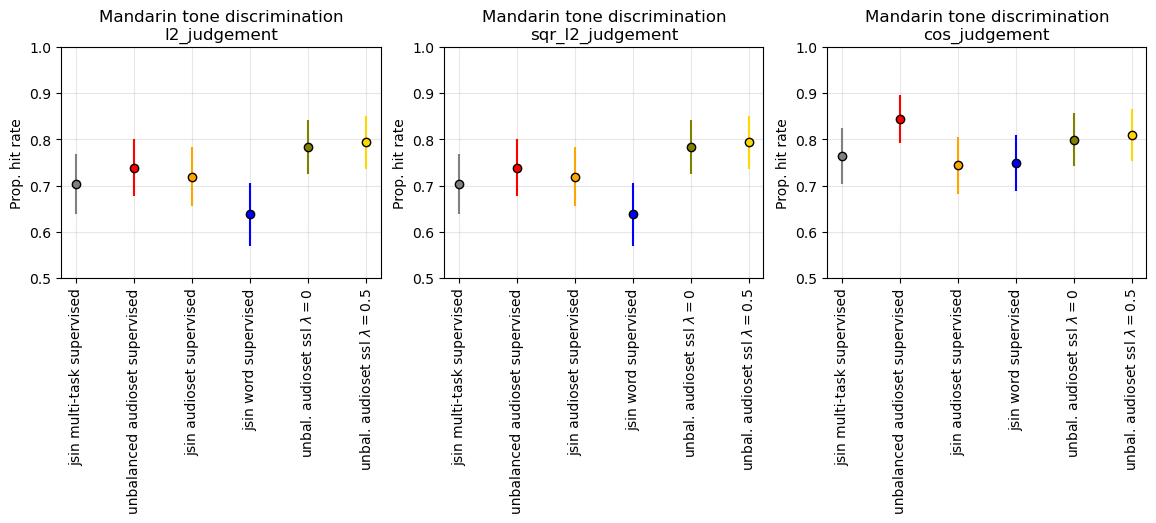

In [15]:
fig, axes = plt.subplots(1, 3,  figsize=(14, 3), constrained_layout=False)
models_order = triplet_df.model.unique()

palette = {
    "multitask_model": "grey",
    "unbal_audioset_model": "red",
    "audioset_model": "orange",
    "word_model": "blue",
    "ssl_lambda_0_model": "olive",
    "ssl_lambda_5_model": "gold",
}
model_labels = [
    "jsin multi-task supervised",
    "unbalanced audioset supervised",
    "jsin audioset supervised",
    "jsin word supervised",
    "unbal. audioset ssl $\\lambda=0$",
    "unbal. audioset ssl $\\lambda=0.5$",
]
# plot mean judgement for each model
for ix, metric in enumerate(["l2_judgement", "sqr_l2_judgement", "cos_judgement"]):
    for model in models_order:
        mean_loss = triplet_df[triplet_df.model == model][metric].mean()   
        error = 2 * triplet_df[triplet_df.model == model][metric].std() / np.sqrt(len(triplet_df[triplet_df.model == model]))
        axes[ix].errorbar(
            [model],
            [mean_loss],
            fmt='o',
            yerr=error,
            label=model,
            color=palette[model],
            # add marker edge color
            markeredgecolor="k",
        )
    axes[ix].set_title(f"Mandarin tone discrimination\n{metric}")
    axes[ix].set_ylabel("Prop. hit rate")
    axes[ix].grid(True, alpha=0.3)
    axes[ix].set_ylim(0.5, 1)

    axes[ix].set_xticklabels(model_labels, rotation=90, ha='center')

plt.show()

/tmp/ipykernel_313142/275650650.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(model_labels, rotation=90, ha='center')


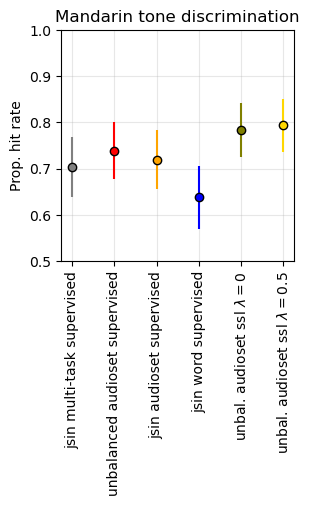

In [16]:
fig, axes = plt.subplots(1,  figsize=(3, 3), constrained_layout=False)
models_order = triplet_df.model.unique()

palette = {
    "multitask_model": "grey",
    "audioset_model": "orange",
    "unbal_audioset_model": "red",
    "word_model": "blue",
    "ssl_lambda_0_model": "olive",
    "ssl_lambda_5_model": "gold",
}
# plot mean judgement for each model
for model in models_order:
    mean_loss = triplet_df[triplet_df.model == model].sqr_l2_judgement.mean()   
    error = 2 * triplet_df[triplet_df.model == model].sqr_l2_judgement.std() / np.sqrt(len(triplet_df[triplet_df.model == model]))
    axes.errorbar(
        [model],
        [mean_loss],
        fmt='o',
        yerr=error,
        label=model,
        color=palette[model],
        # add marker edge color
        markeredgecolor="k",
    )
axes.set_title("Mandarin tone discrimination")
axes.set_ylabel("Prop. hit rate")
axes.grid(True, alpha=0.3)
axes.set_ylim(0.5, 1)

model_labels = [
    "jsin multi-task supervised",
    "unbalanced audioset supervised",
    "jsin audioset supervised",
    "jsin word supervised",
    "unbal. audioset ssl $\\lambda=0$",
    "unbal. audioset ssl $\\lambda=0.5$",
]
axes.set_xticklabels(model_labels, rotation=90, ha='center')

plt.show()